In [145]:
# =========================================
# 2.1 - KHẢO SÁT VÀ TÌM HIỂU DỮ LIỆU
# Cell 1: Import thư viện
# =========================================
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

sns.set_theme(style="whitegrid")

In [146]:
# =========================================
# Cell 2: Khai báo đường dẫn dữ liệu
# =========================================
DATA_DIR = Path(".")   # nếu file csv cùng thư mục notebook
# DATA_DIR = Path("/mnt/data")   # nếu chạy trên môi trường có file ở /mnt/data

files = {
    "customers": "olist_customers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "order_payments": "olist_order_payments_dataset.csv",
    "order_reviews": "olist_order_reviews_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}

In [147]:
# =========================================
# Cell 3: Đọc 9 file CSV
# =========================================
customers = pd.read_csv(DATA_DIR / files["customers"])
geolocation = pd.read_csv(DATA_DIR / files["geolocation"])
order_items = pd.read_csv(DATA_DIR / files["order_items"])
order_payments = pd.read_csv(DATA_DIR / files["order_payments"])
order_reviews = pd.read_csv(DATA_DIR / files["order_reviews"])
orders = pd.read_csv(DATA_DIR / files["orders"])
products = pd.read_csv(DATA_DIR / files["products"])
sellers = pd.read_csv(DATA_DIR / files["sellers"])
category_translation = pd.read_csv(DATA_DIR / files["category_translation"])

tables = {
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
    "category_translation": category_translation,
}

print("Đã load xong 9 bảng dữ liệu.")

Đã load xong 9 bảng dữ liệu.


In [148]:
# =========================================
# Cell 4: Xem kích thước từng bảng
# =========================================
shape_summary = pd.DataFrame({
    "table_name": list(tables.keys()),
    "n_rows": [df.shape[0] for df in tables.values()],
    "n_cols": [df.shape[1] for df in tables.values()],
})

shape_summary

,table_name,n_rows,n_cols
0,customers,99441,5
1,geolocation,1000163,5
2,order_items,112650,7
3,order_payments,103886,5
4,order_reviews,99224,7
5,orders,99441,8
6,products,32951,9
7,sellers,3095,4
8,category_translation,71,2


In [149]:
# =========================================
# Cell 5: Xem nhanh từng bảng
# =========================================
for name, df in tables.items():
    print(f"\n===== {name.upper()} =====")
    display(df.head(3))


===== CUSTOMERS =====


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



===== GEOLOCATION =====


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP



===== ORDER_ITEMS =====


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0



===== SELLERS =====


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ



===== CATEGORY_TRANSLATION =====


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


In [150]:
# =========================================
# Cell 6: Mô tả quan hệ giữa các bảng
# =========================================
relationship_df = pd.DataFrame([
    ["orders", "customers", "customer_id", "N:1", "Một khách hàng có thể có nhiều đơn hàng"],
    ["orders", "order_items", "order_id", "1:N", "Một đơn hàng có thể có nhiều sản phẩm"],
    ["orders", "order_payments", "order_id", "1:N", "Một đơn hàng có thể có nhiều lần thanh toán"],
    ["orders", "order_reviews", "order_id", "1:1 hoặc 1:N", "Một đơn có thể có review, thực tế có thể nhiều bản ghi theo order_id"],
    ["order_items", "products", "product_id", "N:1", "Nhiều item có thể cùng một sản phẩm"],
    ["order_items", "sellers", "seller_id", "N:1", "Nhiều item có thể cùng một người bán"],
    ["products", "category_translation", "product_category_name", "N:1", "Chuẩn hóa tên danh mục sang tiếng Anh"],
    ["customers", "geolocation", "zip_code_prefix", "N:1 gần đúng", "Nối theo customer_zip_code_prefix và geolocation_zip_code_prefix"],
    ["sellers", "geolocation", "zip_code_prefix", "N:1 gần đúng", "Nối theo seller_zip_code_prefix và geolocation_zip_code_prefix"],
], columns=["left_table", "right_table", "join_key", "cardinality", "note"])

relationship_df

,left_table,right_table,join_key,cardinality,note
0,orders,customers,customer_id,N:1,Một khách hàng có thể có nhiều đơn hàng
1,orders,order_items,order_id,1:N,Một đơn hàng có thể có nhiều sản phẩm
2,orders,order_payments,order_id,1:N,Một đơn hàng có thể có nhiều lần thanh toán
3,orders,order_reviews,order_id,1:1 hoặc 1:N,"Một đơn có thể có review, thực tế có thể nhiều..."
4,order_items,products,product_id,N:1,Nhiều item có thể cùng một sản phẩm
5,order_items,sellers,seller_id,N:1,Nhiều item có thể cùng một người bán
6,products,category_translation,product_category_name,N:1,Chuẩn hóa tên danh mục sang tiếng Anh
7,customers,geolocation,zip_code_prefix,N:1 gần đúng,Nối theo customer_zip_code_prefix và geolocati...
8,sellers,geolocation,zip_code_prefix,N:1 gần đúng,Nối theo seller_zip_code_prefix và geolocation...


In [151]:
# =========================================
# Cell 7: Kiểu dữ liệu và số lượng non-null
# =========================================
for name, df in tables.items():
    print(f"\n===== INFO: {name.upper()} =====")
    df.info()


===== INFO: CUSTOMERS =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

===== INFO: GEOLOCATION =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  

In [152]:
# =========================================
# Cell 8: Thống kê mô tả bằng .describe()
# =========================================
for name, df in tables.items():
    print(f"\n===== DESCRIBE: {name.upper()} =====")
    display(df.describe(include="all").T.head(20))


===== DESCRIBE: CUSTOMERS =====


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,99441,99441,06b8999e2fba1a1fbc88172c00ba8bc7,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_unique_id,99441,96096,8d50f5eadf50201ccdcedfb9e2ac8455,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_zip_code_prefix,99441.0,NaN,NaN,NaN,35137.474583,29797.938996,1003.0,11347.0,24416.0,58900.0,99990.0
customer_city,99441,4119,sao paulo,15540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_state,99441,27,SP,41746,NaN,NaN,NaN,NaN,NaN,NaN,NaN



===== DESCRIBE: GEOLOCATION =====


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
geolocation_zip_code_prefix,1000163.0,NaN,NaN,NaN,36574.166466,30549.33571,1001.0,11075.0,26530.0,63504.0,99990.0
geolocation_lat,1000163.0,NaN,NaN,NaN,-21.176153,5.715866,-36.605374,-23.603546,-22.919377,-19.97962,45.065933
geolocation_lng,1000163.0,NaN,NaN,NaN,-46.390541,4.269748,-101.466766,-48.573172,-46.637879,-43.767709,121.105394
geolocation_city,1000163,8011,sao paulo,135800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
geolocation_state,1000163,27,SP,404268,NaN,NaN,NaN,NaN,NaN,NaN,NaN



===== DESCRIBE: ORDER_ITEMS =====


...

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_id,32951,32951,1e9e8ef04dbcff4541ed26657ea517e5,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_category_name,32341,73,cama_mesa_banho,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_name_lenght,32341.0,NaN,NaN,NaN,48.476949,10.245741,5.0,42.0,51.0,57.0,76.0
product_description_lenght,32341.0,NaN,NaN,NaN,771.495285,635.115225,4.0,339.0,595.0,972.0,3992.0
product_photos_qty,32341.0,NaN,NaN,NaN,2.188986,1.736766,1.0,1.0,1.0,3.0,20.0
product_weight_g,32949.0,NaN,NaN,NaN,2276.472488,4282.038731,0.0,300.0,700.0,1900.0,40425.0
product_length_cm,32949.0,NaN,NaN,NaN,30.815078,16.914458,7.0,18.0,25.0,38.0,105.0
product_height_cm,32949.0,NaN,NaN,NaN,16.937661,13.637554,2.0,8.0,13.0,21.0,105.0
product_width_cm,32949.0,NaN,NaN,NaN,23.196728,12.079047,6.0,15.0,20.0,30.0,118.0



===== DESCRIBE: SELLERS =====


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
seller_id,3095,3095,3442f8959a84dea7ee197c632cb2df15,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_zip_code_prefix,3095.0,NaN,NaN,NaN,32291.059451,32713.45383,1001.0,7093.5,14940.0,64552.5,99730.0
seller_city,3095,611,sao paulo,694,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_state,3095,23,SP,1849,NaN,NaN,NaN,NaN,NaN,NaN,NaN



===== DESCRIBE: CATEGORY_TRANSLATION =====


,count,unique,top,freq
product_category_name,71,71,beleza_saude,1
product_category_name_english,71,71,health_beauty,1


In [153]:
# =========================================
# Cell 9: Missing values
# =========================================
missing_summary = []

for name, df in tables.items():
    tmp = pd.DataFrame({
        "table_name": name,
        "column_name": df.columns,
        "missing_count": df.isnull().sum().values,
        "missing_pct": (df.isnull().mean().values * 100).round(2)
    })
    missing_summary.append(tmp)

missing_summary = pd.concat(missing_summary, ignore_index=True)
missing_summary = missing_summary.sort_values(["missing_pct", "missing_count"], ascending=False)

missing_summary.head(30)

,table_name,column_name,missing_count,missing_pct
25,order_reviews,review_comment_title,87656,88.34
26,order_reviews,review_comment_message,58247,58.70
35,orders,order_delivered_customer_date,2965,2.98
38,products,product_category_name,610,1.85
39,products,product_name_lenght,610,1.85
40,products,product_description_lenght,610,1.85
41,products,product_photos_qty,610,1.85
34,orders,order_delivered_carrier_date,1783,1.79
33,orders,order_approved_at,160,0.16
42,products,product_weight_g,2,0.01


In [154]:
# =========================================
# Cell 10: Kiểm tra riêng review_comment_message
# =========================================
review_null_count = order_reviews["review_comment_message"].isnull().sum()
review_null_pct = order_reviews["review_comment_message"].isnull().mean() * 100

print("Số lượng null của review_comment_message:", review_null_count)
print("Tỷ lệ null của review_comment_message: {:.2f}%".format(review_null_pct))

Số lượng null của review_comment_message: 58247
Tỷ lệ null của review_comment_message: 58.70%


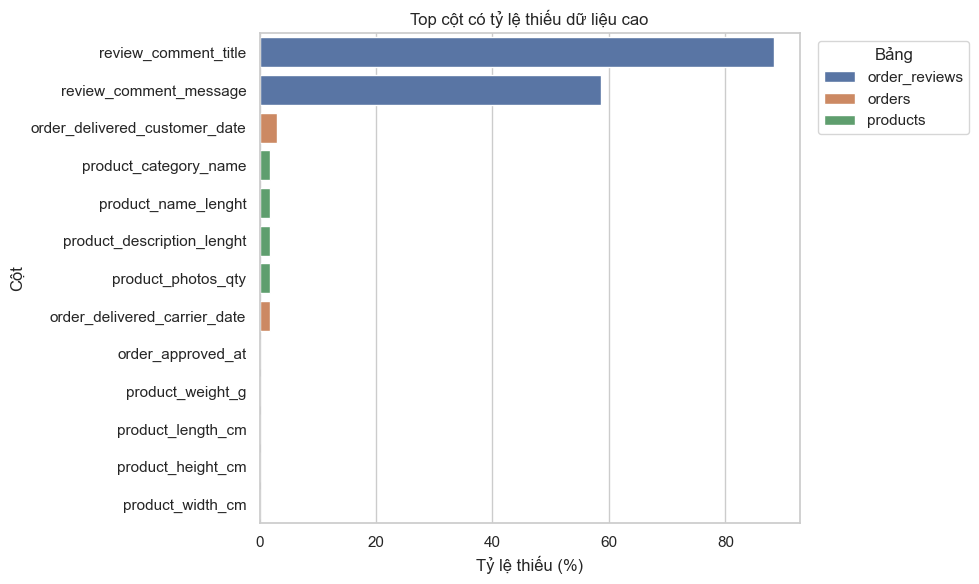

In [155]:
# =========================================
# Cell 11: Biểu đồ missing values
# =========================================
top_missing = missing_summary[missing_summary["missing_count"] > 0].head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_missing,
    x="missing_pct",
    y="column_name",
    hue="table_name",
    dodge=False
)
plt.title("Top cột có tỷ lệ thiếu dữ liệu cao")
plt.xlabel("Tỷ lệ thiếu (%)")
plt.ylabel("Cột")
plt.legend(title="Bảng", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [156]:
# =========================================
# Cell 12: Kiểm tra duplicate toàn dòng
# =========================================
dup_full_rows = pd.DataFrame({
    "table_name": list(tables.keys()),
    "duplicate_full_rows": [df.duplicated().sum() for df in tables.values()]
})

dup_full_rows

,table_name,duplicate_full_rows
0,customers,0
1,geolocation,261831
2,order_items,0
3,order_payments,0
4,order_reviews,0
5,orders,0
6,products,0
7,sellers,0
8,category_translation,0


In [157]:
# =========================================
# Cell 13: Duplicate theo khóa chính / khóa ghép
# =========================================
duplicate_keys = {
    "customers_customer_id": customers.duplicated(subset=["customer_id"]).sum(),
    "orders_order_id": orders.duplicated(subset=["order_id"]).sum(),
    "products_product_id": products.duplicated(subset=["product_id"]).sum(),
    "sellers_seller_id": sellers.duplicated(subset=["seller_id"]).sum(),
    "order_reviews_review_id": order_reviews.duplicated(subset=["review_id"]).sum(),
    "order_items_order_item_key": order_items.duplicated(subset=["order_id", "order_item_id"]).sum(),
    "order_payments_payment_key": order_payments.duplicated(subset=["order_id", "payment_sequential"]).sum(),
}

pd.DataFrame(
    duplicate_keys.items(),
    columns=["key_name", "duplicate_count"]
)

,key_name,duplicate_count
0,customers_customer_id,0
1,orders_order_id,0
2,products_product_id,0
3,sellers_seller_id,0
4,order_reviews_review_id,814
5,order_items_order_item_key,0
6,order_payments_payment_key,0


In [158]:
# =========================================
# Cell 14: Chuyển đổi cột thời gian
# =========================================
orders = orders.copy()
order_items = order_items.copy()
order_reviews = order_reviews.copy()

order_date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in order_date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

order_items["shipping_limit_date"] = pd.to_datetime(order_items["shipping_limit_date"], errors="coerce")

review_date_cols = ["review_creation_date", "review_answer_timestamp"]
for col in review_date_cols:
    order_reviews[col] = pd.to_datetime(order_reviews[col], errors="coerce")

print("Đã chuyển đổi các cột thời gian xong.")
orders[order_date_cols].dtypes

Đã chuyển đổi các cột thời gian xong.


order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [159]:
# =========================================
# Cell 15: Kiểm tra độ phủ liên kết giữa các bảng
# =========================================
coverage_df = pd.DataFrame([
    {
        "relationship": "orders -> customers",
        "left_count": orders["customer_id"].nunique(),
        "matched_in_right": orders["customer_id"].isin(customers["customer_id"]).sum(),
        "coverage_pct": round(orders["customer_id"].isin(customers["customer_id"]).mean() * 100, 2)
    },
    {
        "relationship": "order_items -> orders",
        "left_count": order_items["order_id"].nunique(),
        "matched_in_right": order_items["order_id"].isin(orders["order_id"]).sum(),
        "coverage_pct": round(order_items["order_id"].isin(orders["order_id"]).mean() * 100, 2)
    },
    {
        "relationship": "order_payments -> orders",
        "left_count": order_payments["order_id"].nunique(),
        "matched_in_right": order_payments["order_id"].isin(orders["order_id"]).sum(),
        "coverage_pct": round(order_payments["order_id"].isin(orders["order_id"]).mean() * 100, 2)
    },
    {
        "relationship": "order_reviews -> orders",
        "left_count": order_reviews["order_id"].nunique(),
        "matched_in_right": order_reviews["order_id"].isin(orders["order_id"]).sum(),
        "coverage_pct": round(order_reviews["order_id"].isin(orders["order_id"]).mean() * 100, 2)
    },
    {
        "relationship": "order_items -> products",
        "left_count": order_items["product_id"].nunique(),
        "matched_in_right": order_items["product_id"].isin(products["product_id"]).sum(),
        "coverage_pct": round(order_items["product_id"].isin(products["product_id"]).mean() * 100, 2)
    },
    {
        "relationship": "order_items -> sellers",
        "left_count": order_items["seller_id"].nunique(),
        "matched_in_right": order_items["seller_id"].isin(sellers["seller_id"]).sum(),
        "coverage_pct": round(order_items["seller_id"].isin(sellers["seller_id"]).mean() * 100, 2)
    }
])

coverage_df

,relationship,left_count,matched_in_right,coverage_pct
0,orders -> customers,99441,99441,100.0
1,order_items -> orders,98666,112650,100.0
2,order_payments -> orders,99440,103886,100.0
3,order_reviews -> orders,98673,99224,100.0
4,order_items -> products,32951,112650,100.0
5,order_items -> sellers,3095,112650,100.0


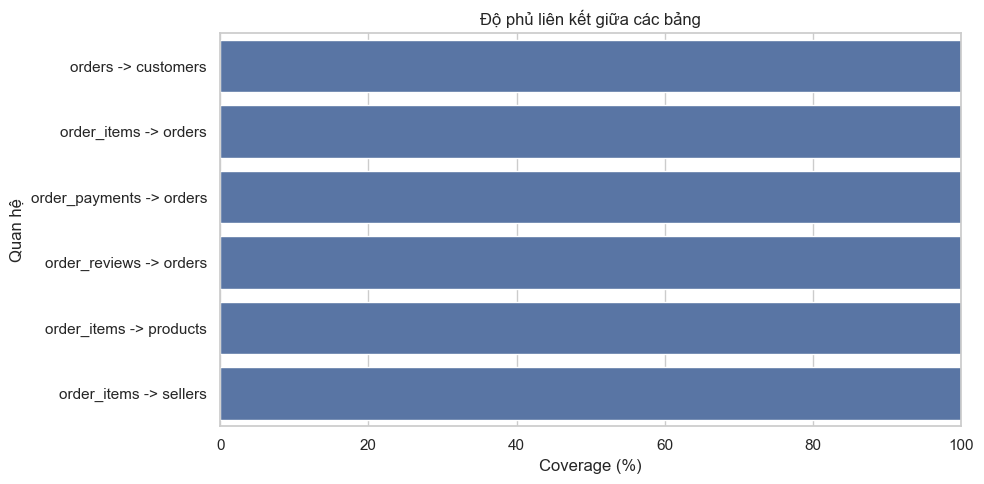

In [160]:
# =========================================
# Cell mới B: Trực quan độ phủ liên kết
# Đặt sau Cell 15: Kiểm tra độ phủ liên kết giữa các bảng
# =========================================
coverage_plot = coverage_df.sort_values("coverage_pct", ascending=True)

plt.figure(figsize=(10, 5))
sns.barplot(data=coverage_plot, x="coverage_pct", y="relationship")
plt.title("Độ phủ liên kết giữa các bảng")
plt.xlabel("Coverage (%)")
plt.ylabel("Quan hệ")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

In [161]:
# =========================================
# Cell 16: Tạo orders_base để EDA
# =========================================

# Join category translation vào products
products_en = products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

products_en["product_category_name_english"] = products_en["product_category_name_english"].fillna("unknown")

# Tổng hợp order_items
items_agg = (
    order_items
    .merge(products_en[["product_id", "product_category_name_english"]], on="product_id", how="left")
    .groupby("order_id", as_index=False)
    .agg(
        item_count=("order_item_id", "count"),
        unique_products=("product_id", "nunique"),
        unique_sellers=("seller_id", "nunique"),
        price_sum=("price", "sum"),
        freight_value_sum=("freight_value", "sum"),
        price_mean=("price", "mean"),
        main_category=("product_category_name_english",
                       lambda x: x.mode().iloc[0] if not x.mode().empty else "unknown")
    )
)

# Tổng hợp payments
payments_agg = (
    order_payments
    .groupby("order_id", as_index=False)
    .agg(
        payment_value_sum=("payment_value", "sum"),
        payment_installments_max=("payment_installments", "max"),
        payment_type_mode=("payment_type",
                           lambda x: x.mode().iloc[0] if not x.mode().empty else "unknown")
    )
)

# Chuẩn bị reviews
order_reviews["review_comment_message"] = order_reviews["review_comment_message"].fillna("")
order_reviews["review_comment_length"] = order_reviews["review_comment_message"].str.len()
order_reviews["has_comment"] = (order_reviews["review_comment_length"] > 0).astype(int)

reviews_agg = (
    order_reviews
    .sort_values("review_answer_timestamp")
    .groupby("order_id", as_index=False)
    .agg(
        review_score=("review_score", "last"),
        review_comment_message=("review_comment_message", "last"),
        review_comment_length=("review_comment_length", "last"),
        has_comment=("has_comment", "max")
    )
)

# Merge thành bảng order-level
orders_base = (
    orders
    .merge(customers, on="customer_id", how="left")
    .merge(items_agg, on="order_id", how="left")
    .merge(payments_agg, on="order_id", how="left")
    .merge(reviews_agg, on="order_id", how="left")
)

orders_base.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,item_count,unique_products,unique_sellers,price_sum,freight_value_sum,price_mean,main_category,payment_value_sum,payment_installments_max,payment_type_mode,review_score,review_comment_message,review_comment_length,has_comment
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,1.0,1.0,29.99,8.72,29.99,housewares,38.71,1.0,voucher,4.0,"Não testei o produto ainda, mas ele veio corre...",170.0,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,1.0,1.0,118.70,22.76,118.70,perfumery,141.46,1.0,boleto,4.0,Muito bom o produto.,20.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,1.0,1.0,159.90,19.22,159.90,auto,179.12,3.0,credit_card,5.0,,0.0,0.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,1.0,1.0,45.00,27.20,45.00,pet_shop,72.20,1.0,credit_card,5.0,O produto foi exatamente o que eu esperava e e...,105.0,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,1.0,1.0,19.90,8.72,19.90,stationery,28.62,1.0,credit_card,5.0,,0.0,0.0


In [162]:
# =========================================
# Cell 17: Tạo cột dẫn xuất
# =========================================
orders_base["delivery_time_days"] = (
    orders_base["order_delivered_customer_date"] - orders_base["order_purchase_timestamp"]
).dt.total_seconds() / 86400

orders_base["delivery_delay_days"] = (
    orders_base["order_delivered_customer_date"] - orders_base["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

orders_base["approval_time_hours"] = (
    orders_base["order_approved_at"] - orders_base["order_purchase_timestamp"]
).dt.total_seconds() / 3600

orders_base["purchase_year"] = orders_base["order_purchase_timestamp"].dt.year
orders_base["purchase_month"] = orders_base["order_purchase_timestamp"].dt.month
orders_base["purchase_dayofweek"] = orders_base["order_purchase_timestamp"].dt.dayofweek

orders_base[[
    "order_id",
    "delivery_time_days",
    "delivery_delay_days",
    "approval_time_hours",
    "purchase_year",
    "purchase_month",
    "purchase_dayofweek"
]].head()

,order_id,delivery_time_days,delivery_delay_days,approval_time_hours,purchase_year,purchase_month,purchase_dayofweek
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,-7.107488,0.178333,2017,10,0
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,-5.355729,30.713889,2018,7,1
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,-17.245498,0.276111,2018,8,2
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750,-12.980069,0.298056,2017,11,5
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877,-9.238171,1.030556,2018,2,1


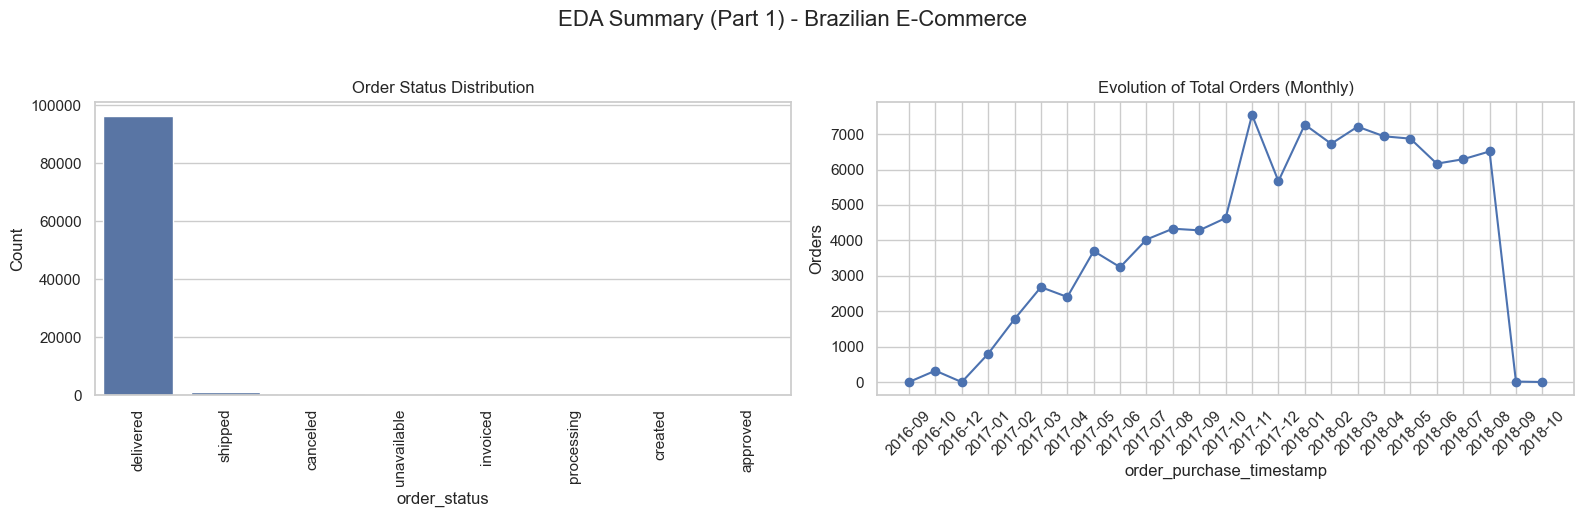

In [163]:
# =========================================
# Cell mới C1: EDA Summary - 2 biểu đồ đầu
# Đặt sau Cell 17: Tạo cột dẫn xuất
# =========================================
eda_df = orders_base.copy()
eda_df = eda_df.dropna(subset=["order_purchase_timestamp"]).copy()

# Tạo thêm biến giờ mua và nhóm thời điểm trong ngày
eda_df["purchase_hour"] = eda_df["order_purchase_timestamp"].dt.hour

day_map = {
    0: "Monday", 1: "Tuesday", 2: "Wednesday", 3: "Thursday",
    4: "Friday", 5: "Saturday", 6: "Sunday"
}
eda_df["purchase_dayofweek_name"] = eda_df["purchase_dayofweek"].map(day_map)

eda_df["order_time_day"] = pd.cut(
    eda_df["purchase_hour"],
    bins=[-1, 5, 11, 17, 23],
    labels=["Dawn", "Morning", "Afternoon", "Night"]
)

# Tổng số đơn theo tháng
monthly_orders = (
    eda_df
    .groupby(eda_df["order_purchase_timestamp"].dt.to_period("M"))
    .size()
    .reset_index(name="orders")
)
monthly_orders["order_purchase_timestamp"] = monthly_orders["order_purchase_timestamp"].astype(str)

# Vẽ 2 biểu đồ đầu
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Order status
status_order = eda_df["order_status"].value_counts().index
sns.countplot(data=eda_df, x="order_status", order=status_order, ax=axes[0])
axes[0].set_title("Order Status Distribution")
axes[0].set_xlabel("order_status")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=90)

# 2. Monthly orders
axes[1].plot(monthly_orders["order_purchase_timestamp"], monthly_orders["orders"], marker="o")
axes[1].set_title("Evolution of Total Orders (Monthly)")
axes[1].set_xlabel("order_purchase_timestamp")
axes[1].set_ylabel("Orders")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("EDA Summary (Part 1) - Brazilian E-Commerce", fontsize=16, y=1.03)
plt.tight_layout()
plt.show()



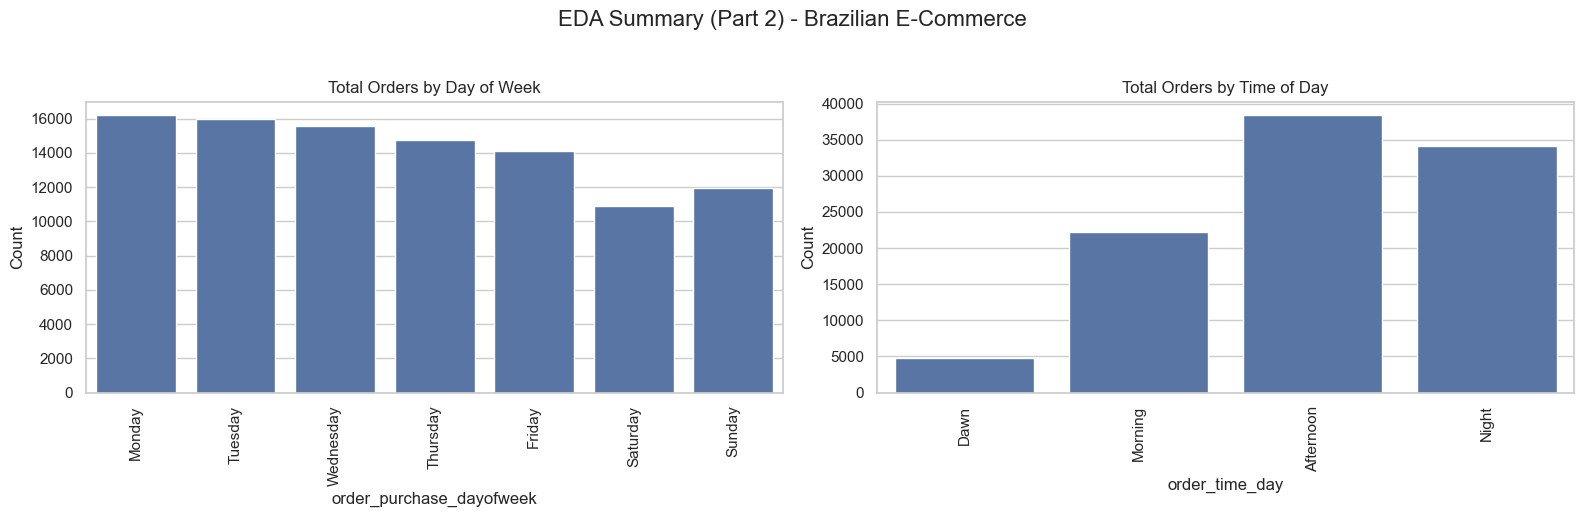

In [164]:
# =========================================
# Cell mới C2: EDA Summary - 2 biểu đồ sau
# Bản độc lập
# =========================================
eda_df = orders_base.copy()
eda_df = eda_df.dropna(subset=["order_purchase_timestamp"]).copy()

eda_df["purchase_hour"] = eda_df["order_purchase_timestamp"].dt.hour

day_map = {
    0: "Monday", 1: "Tuesday", 2: "Wednesday", 3: "Thursday",
    4: "Friday", 5: "Saturday", 6: "Sunday"
}
eda_df["purchase_dayofweek_name"] = eda_df["purchase_dayofweek"].map(day_map)

eda_df["order_time_day"] = pd.cut(
    eda_df["purchase_hour"],
    bins=[-1, 5, 11, 17, 23],
    labels=["Dawn", "Morning", "Afternoon", "Night"]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Orders by day of week
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sns.countplot(data=eda_df, x="purchase_dayofweek_name", order=weekday_order, ax=axes[0])
axes[0].set_title("Total Orders by Day of Week")
axes[0].set_xlabel("order_purchase_dayofweek")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=90)

# 2. Orders by time of day
time_order = ["Dawn", "Morning", "Afternoon", "Night"]
sns.countplot(data=eda_df, x="order_time_day", order=time_order, ax=axes[1])
axes[1].set_title("Total Orders by Time of Day")
axes[1].set_xlabel("order_time_day")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=90)

plt.suptitle("EDA Summary (Part 2) - Brazilian E-Commerce", fontsize=16, y=1.03)
plt.tight_layout()
plt.show()

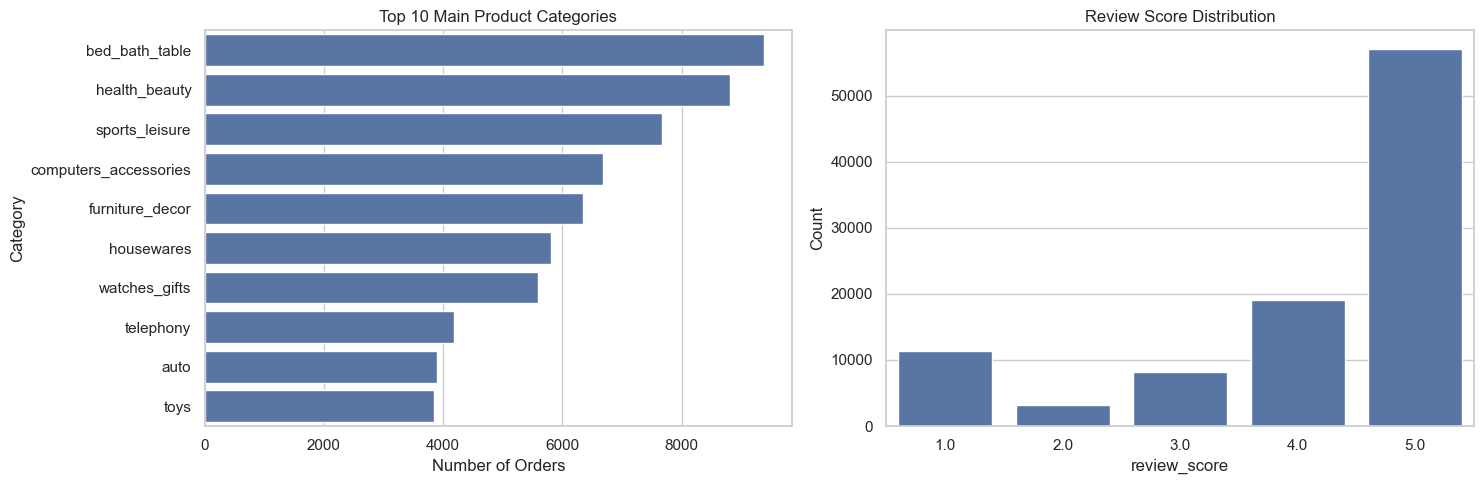

In [165]:
# =========================================
# Cell mới D: Top danh mục sản phẩm và phân bố review score
# Đặt sau Cell mới C hoặc sau Cell 17
# =========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Top category
top_categories = (
    orders_base["main_category"]
    .fillna("unknown")
    .value_counts()
    .head(10)
)

sns.barplot(x=top_categories.values, y=top_categories.index, ax=axes[0])
axes[0].set_title("Top 10 Main Product Categories")
axes[0].set_xlabel("Number of Orders")
axes[0].set_ylabel("Category")

# Review score distribution
review_order = sorted(orders_base["review_score"].dropna().unique())
sns.countplot(data=orders_base, x="review_score", order=review_order, ax=axes[1])
axes[1].set_title("Review Score Distribution")
axes[1].set_xlabel("review_score")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [166]:
# =========================================
# Cell 18: Describe cho orders_base
# =========================================
orders_base.describe(include="all").T.head(30)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_id,99441,99441,e481f51cbdc54678b7cc49136f2d6af7,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,99441,99441,9ef432eb6251297304e76186b10a928d,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_status,99441,8,delivered,96478,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_purchase_timestamp,99441,NaN,NaN,NaN,2017-12-31 08:43:12.776581120,2016-09-04 21:15:19,2017-09-12 14:46:19,2018-01-18 23:04:36,2018-05-04 15:42:16,2018-10-17 17:30:18,NaN
order_approved_at,99281,NaN,NaN,NaN,2017-12-31 18:35:24.098800128,2016-09-15 12:16:38,2017-09-12 23:24:16,2018-01-19 11:36:13,2018-05-04 20:35:10,2018-09-03 17:40:06,NaN
order_delivered_carrier_date,97658,NaN,NaN,NaN,2018-01-04 21:49:48.138278656,2016-10-08 10:34:01,2017-09-15 22:28:50.249999872,2018-01-24 16:10:58,2018-05-08 13:37:45,2018-09-11 19:48:28,NaN
order_delivered_customer_date,96476,NaN,NaN,NaN,2018-01-14 12:09:19.035542272,2016-10-11 13:46:32,2017-09-25 22:07:22.249999872,2018-02-02 19:28:10.500000,2018-05-15 22:48:52.249999872,2018-10-17 13:22:46,NaN
order_estimated_delivery_date,99441,NaN,NaN,NaN,2018-01-24 03:08:37.730111232,2016-09-30 00:00:00,2017-10-03 00:00:00,2018-02-15 00:00:00,2018-05-25 00:00:00,2018-11-12 00:00:00,NaN
customer_unique_id,99441,96096,8d50f5eadf50201ccdcedfb9e2ac8455,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_zip_code_prefix,99441.0,NaN,NaN,NaN,35137.474583,1003.0,11347.0,24416.0,58900.0,99990.0,29797.938996


In [167]:
# =========================================
# Cell 19: Chuẩn bị RFM
# =========================================
delivered_df = orders_base[orders_base["order_status"] == "delivered"].copy()

reference_date = delivered_df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = (
    delivered_df
    .groupby("customer_unique_id", as_index=False)
    .agg(
        recency_days=("order_purchase_timestamp", lambda x: (reference_date - x.max()).days),
        frequency_orders=("order_id", "nunique"),
        monetary_value=("payment_value_sum", "sum")
    )
)

rfm.head()

,customer_unique_id,recency_days,frequency_orders,monetary_value
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


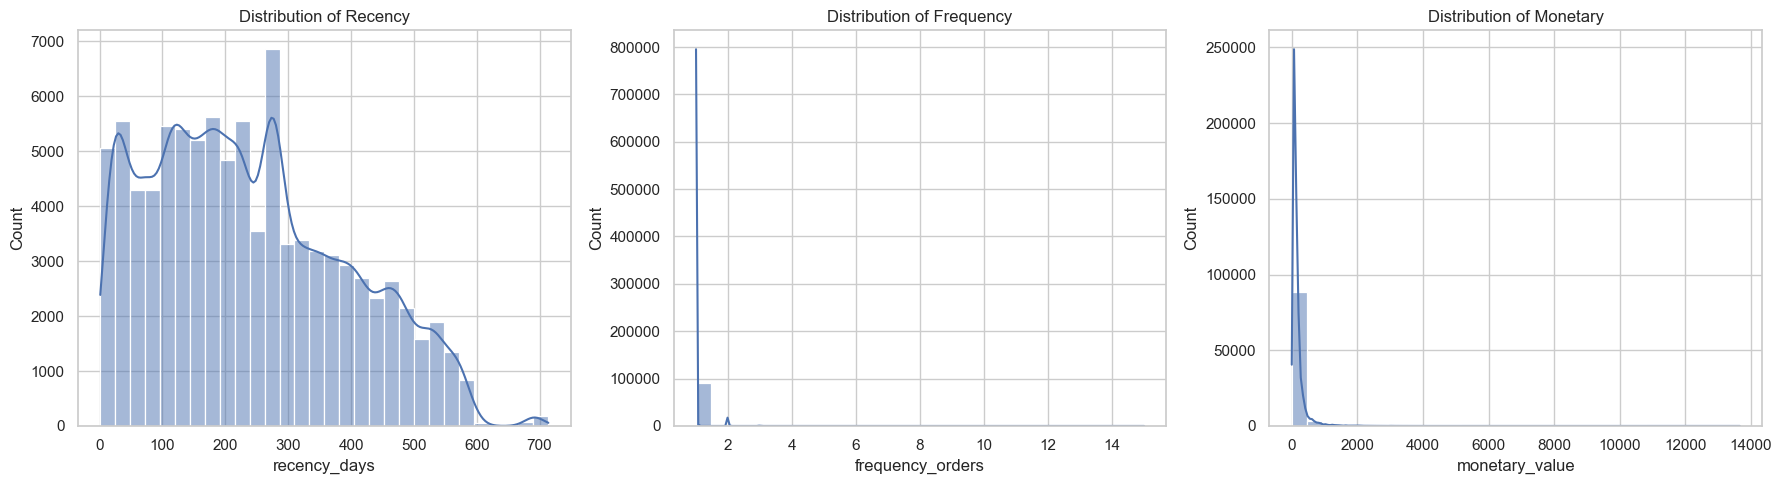

In [168]:
# =========================================
# Cell mới E: Trực quan phân bố RFM
# Đặt sau Cell 19: Chuẩn bị RFM
# =========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm["recency_days"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Recency")
axes[0].set_xlabel("recency_days")

sns.histplot(rfm["frequency_orders"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Frequency")
axes[1].set_xlabel("frequency_orders")

sns.histplot(rfm["monetary_value"], bins=30, kde=True, ax=axes[2])
axes[2].set_title("Distribution of Monetary")
axes[2].set_xlabel("monetary_value")

plt.tight_layout()
plt.show()

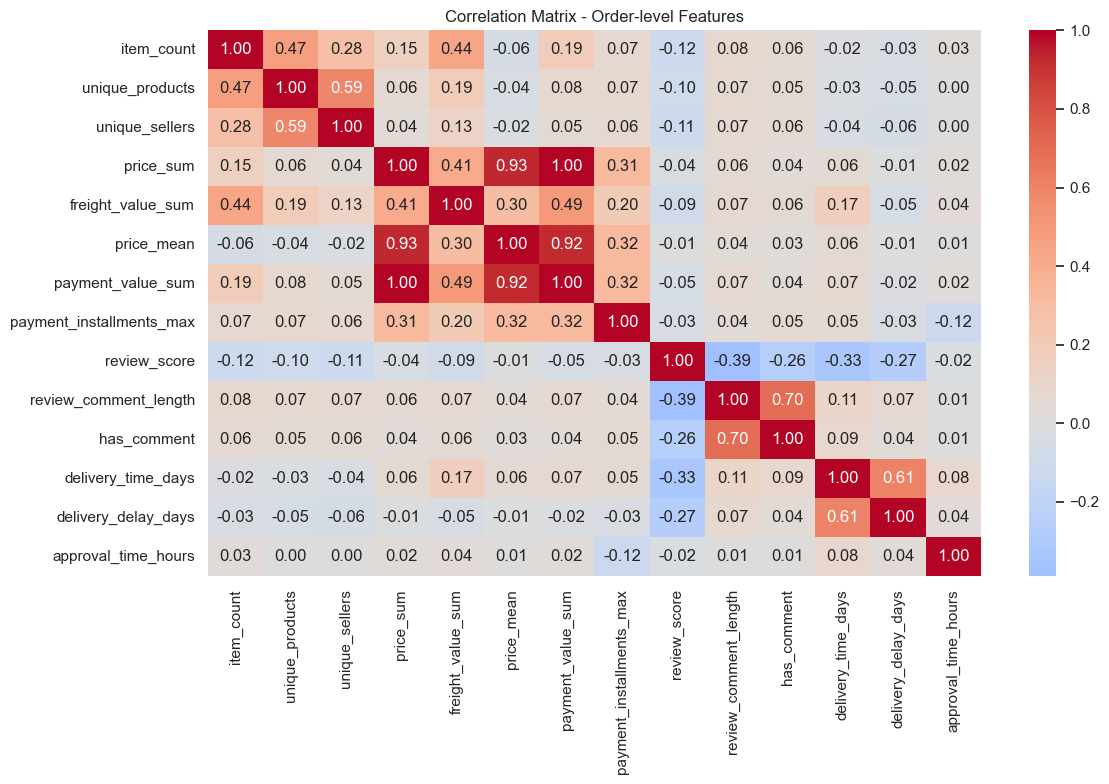

In [169]:
# =========================================
# Cell 20: Correlation matrix
# =========================================
corr_cols = [
    "item_count",
    "unique_products",
    "unique_sellers",
    "price_sum",
    "freight_value_sum",
    "price_mean",
    "payment_value_sum",
    "payment_installments_max",
    "review_score",
    "review_comment_length",
    "has_comment",
    "delivery_time_days",
    "delivery_delay_days",
    "approval_time_hours"
]

corr_cols = [c for c in corr_cols if c in orders_base.columns]

corr_df = orders_base[corr_cols].copy()
corr_df = corr_df.dropna(axis=1, how="all")

corr_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix - Order-level Features")
plt.tight_layout()
plt.show()

In [170]:
# =========================================
# Cell 21: In ra một số nhận xét nhanh
# =========================================
print("Số bảng đã khảo sát:", len(tables))
print("Tỷ lệ null review_comment_message: {:.2f}%".format(review_null_pct))
print("Kích thước orders_base:", orders_base.shape)
print("Kích thước RFM:", rfm.shape)

Số bảng đã khảo sát: 9
Tỷ lệ null review_comment_message: 58.70%
Kích thước orders_base: (99441, 32)
Kích thước RFM: (93358, 4)


In [171]:
!python -m pip install --upgrade pip
!pip install pandas numpy scikit-learn matplotlib seaborn plotly scipy
!pip install scikit-surprise mlxtend streamlit jupyter notebook joblib

In [172]:
# =========================================
# 2.2 - CÀI ĐẶT MÔI TRƯỜNG PHÁT TRIỂN
# Cell 1: Kiểm tra import thư viện
# =========================================
import sys
import pandas as pd
import numpy as np
import sklearn
import matplotlib
import seaborn as sns
import plotly
import scipy
import joblib

print("Python version:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)
print("plotly:", plotly.__version__)
print("scipy:", scipy.__version__)
print("joblib:", joblib.__version__)

Python version: 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
pandas: 2.3.3
numpy: 1.26.4
scikit-learn: 1.7.2
matplotlib: 3.10.8
seaborn: 0.13.2
plotly: 6.6.0
scipy: 1.15.3
joblib: 1.5.3


In [173]:
# =========================================
# Cell 2: Kiểm tra Surprise, mlxtend, Streamlit
# =========================================
try:
    import surprise
    print("surprise:", surprise.__version__)
except Exception as e:
    print("surprise import error:", e)

try:
    import mlxtend
    print("mlxtend:", mlxtend.__version__)
except Exception as e:
    print("mlxtend import error:", e)

try:
    import streamlit as st
    print("streamlit:", st.__version__)
except Exception as e:
    print("streamlit import error:", e)

surprise: 1.1.4
mlxtend: 0.23.4
streamlit: 1.55.0


In [174]:
# =========================================
# Cell 3: Kiểm tra thư mục làm việc
# =========================================
from pathlib import Path

print("Current working directory:", Path.cwd())
print("Notebook environment ready.")

Current working directory: d:\khanh\monhoc\big_data\bai_ck\archive
Notebook environment ready.


In [175]:
# =========================================
# 2.4 - TIỀN XỬ LÝ DỮ LIỆU (BƯỚC ĐẦU)
# Cell 1: Tạo bản sao dữ liệu
# =========================================
orders_pp = orders.copy()
customers_pp = customers.copy()
order_items_pp = order_items.copy()
order_payments_pp = order_payments.copy()
order_reviews_pp = order_reviews.copy()
products_pp = products.copy()
sellers_pp = sellers.copy()
category_translation_pp = category_translation.copy()

print("Đã tạo bản sao dữ liệu cho bước preprocessing.")

Đã tạo bản sao dữ liệu cho bước preprocessing.


In [176]:
# =========================================
# Cell 2: Merge category translation vào products
# =========================================
products_pp = products_pp.merge(
    category_translation_pp,
    on="product_category_name",
    how="left"
)

products_pp["product_category_name"] = products_pp["product_category_name"].fillna("unknown")
products_pp["product_category_name_english"] = products_pp["product_category_name_english"].fillna("unknown")

products_pp[["product_id", "product_category_name", "product_category_name_english"]].head()

,product_id,product_category_name,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares


In [177]:
# =========================================
# Cell 3: Xử lý null ở bảng reviews
# =========================================
order_reviews_pp["review_comment_title"] = order_reviews_pp["review_comment_title"].fillna("")
order_reviews_pp["review_comment_message"] = order_reviews_pp["review_comment_message"].fillna("")

order_reviews_pp["review_comment_length"] = order_reviews_pp["review_comment_message"].str.len()
order_reviews_pp["has_comment"] = (order_reviews_pp["review_comment_length"] > 0).astype(int)

order_reviews_pp[[
    "review_id",
    "order_id",
    "review_score",
    "review_comment_message",
    "review_comment_length",
    "has_comment"
]].head()

,review_id,order_id,review_score,review_comment_message,review_comment_length,has_comment
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,,0,0
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,,0,0
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,,0,0
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,Recebi bem antes do prazo estipulado.,37,1
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,Parabéns lojas lannister adorei comprar pela I...,100,1


In [178]:
# =========================================
# Cell 4: Aggregation cho order_items
# =========================================
items_en = order_items_pp.merge(
    products_pp[["product_id", "product_category_name_english"]],
    on="product_id",
    how="left"
)

items_agg = (
    items_en
    .groupby("order_id", as_index=False)
    .agg(
        item_count=("order_item_id", "count"),
        unique_products=("product_id", "nunique"),
        unique_sellers=("seller_id", "nunique"),
        price_sum=("price", "sum"),
        freight_value_sum=("freight_value", "sum"),
        price_mean=("price", "mean"),
        main_category=("product_category_name_english",
                       lambda x: x.mode().iloc[0] if not x.mode().empty else "unknown")
    )
)

items_agg.head()

,order_id,item_count,unique_products,unique_sellers,price_sum,freight_value_sum,price_mean,main_category
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,1,58.90,13.29,58.90,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,1,1,239.90,19.93,239.90,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,1,1,199.00,17.87,199.00,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,1,1,12.99,12.79,12.99,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,1,199.90,18.14,199.90,garden_tools


In [179]:
# =========================================
# Cell 5: Aggregation cho order_payments
# =========================================
payments_agg = (
    order_payments_pp
    .groupby("order_id", as_index=False)
    .agg(
        payment_value_sum=("payment_value", "sum"),
        payment_installments_max=("payment_installments", "max"),
        payment_sequential_max=("payment_sequential", "max"),
        payment_type_mode=("payment_type",
                           lambda x: x.mode().iloc[0] if not x.mode().empty else "unknown")
    )
)

payments_agg.head()

,order_id,payment_value_sum,payment_installments_max,payment_sequential_max,payment_type_mode
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1,credit_card


In [180]:
# =========================================
# Cell 6: Aggregation cho order_reviews
# =========================================
reviews_agg = (
    order_reviews_pp
    .sort_values("review_answer_timestamp")
    .groupby("order_id", as_index=False)
    .agg(
        review_score=("review_score", "last"),
        review_comment_message=("review_comment_message", "last"),
        review_comment_length=("review_comment_length", "last"),
        has_comment=("has_comment", "max")
    )
)

reviews_agg.head()

,order_id,review_score,review_comment_message,review_comment_length,has_comment
0,00010242fe8c5a6d1ba2dd792cb16214,5,"Perfeito, produto entregue antes do combinado.",46,1
1,00018f77f2f0320c557190d7a144bdd3,4,,0,0
2,000229ec398224ef6ca0657da4fc703e,5,Chegou antes do prazo previsto e o produto sur...,90,1
3,00024acbcdf0a6daa1e931b038114c75,4,,0,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5,Gostei pois veio no prazo determinado .,39,1


In [181]:
# =========================================
# Cell 7: Merge các bảng thành orders_base
# =========================================
orders_base = (
    orders_pp
    .merge(customers_pp, on="customer_id", how="left")
    .merge(items_agg, on="order_id", how="left")
    .merge(payments_agg, on="order_id", how="left")
    .merge(reviews_agg, on="order_id", how="left")
)

print("Kích thước orders_base:", orders_base.shape)
orders_base.head()

Kích thước orders_base: (99441, 27)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,item_count,unique_products,unique_sellers,price_sum,freight_value_sum,price_mean,main_category,payment_value_sum,payment_installments_max,payment_sequential_max,payment_type_mode,review_score,review_comment_message,review_comment_length,has_comment
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,1.0,1.0,29.99,8.72,29.99,housewares,38.71,1.0,3.0,voucher,4.0,"Não testei o produto ainda, mas ele veio corre...",170.0,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,1.0,1.0,118.70,22.76,118.70,perfumery,141.46,1.0,1.0,boleto,4.0,Muito bom o produto.,20.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,1.0,1.0,159.90,19.22,159.90,auto,179.12,3.0,1.0,credit_card,5.0,,0.0,0.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,1.0,1.0,45.00,27.20,45.00,pet_shop,72.20,1.0,1.0,credit_card,5.0,O produto foi exatamente o que eu esperava e e...,105.0,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,1.0,1.0,19.90,8.72,19.90,stationery,28.62,1.0,1.0,credit_card,5.0,,0.0,0.0


In [182]:
# =========================================
# Cell 8: Kiểm tra missing values sau merge
# =========================================
missing_after_merge = (
    orders_base.isnull().sum()
    .reset_index()
    .rename(columns={"index": "column_name", 0: "missing_count"})
)

missing_after_merge["missing_pct"] = (
    missing_after_merge["missing_count"] / len(orders_base) * 100
).round(2)

missing_after_merge.sort_values("missing_pct", ascending=False).head(20)

,column_name,missing_count,missing_pct
6,order_delivered_customer_date,2965,2.98
5,order_delivered_carrier_date,1783,1.79
13,unique_products,775,0.78
12,item_count,775,0.78
18,main_category,775,0.78
17,price_mean,775,0.78
16,freight_value_sum,775,0.78
15,price_sum,775,0.78
14,unique_sellers,775,0.78
25,review_comment_length,768,0.77


In [183]:
# =========================================
# Cell 9: Xử lý null
# =========================================
# Fill null cho cột số
numeric_fill_zero_cols = [
    "item_count", "unique_products", "unique_sellers",
    "price_sum", "freight_value_sum", "price_mean",
    "payment_value_sum", "payment_installments_max",
    "payment_sequential_max", "review_comment_length", "has_comment"
]

for col in numeric_fill_zero_cols:
    if col in orders_base.columns:
        orders_base[col] = orders_base[col].fillna(0)

# Fill null cho cột phân loại / text
categorical_fill_cols = [
    "main_category",
    "payment_type_mode",
    "review_comment_message"
]

for col in categorical_fill_cols:
    if col in orders_base.columns:
        orders_base[col] = orders_base[col].fillna("unknown")

# Drop những dòng thiếu biến quá quan trọng nếu cần
orders_base = orders_base.dropna(subset=["customer_unique_id", "order_purchase_timestamp"]).copy()

print("Kích thước orders_base sau fill/drop:", orders_base.shape)

Kích thước orders_base sau fill/drop: (99441, 27)


In [184]:
# =========================================
# Cell 10: Ép kiểu dữ liệu
# =========================================
# Numeric
astype_int_cols = ["item_count", "unique_products", "unique_sellers", "has_comment"]
for col in astype_int_cols:
    if col in orders_base.columns:
        orders_base[col] = orders_base[col].astype(int)

# Category / string
astype_str_cols = [
    "order_status",
    "customer_city",
    "customer_state",
    "main_category",
    "payment_type_mode"
]

for col in astype_str_cols:
    if col in orders_base.columns:
        orders_base[col] = orders_base[col].astype(str)

orders_base.dtypes.head(20)
datetime_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in datetime_cols:
    if col in orders_base.columns:
        orders_base[col] = pd.to_datetime(orders_base[col], errors="coerce")

In [185]:
# =========================================
# Cell 11: Tạo cột dẫn xuất về thời gian
# =========================================
orders_base["approval_time_hours"] = (
    orders_base["order_approved_at"] - orders_base["order_purchase_timestamp"]
).dt.total_seconds() / 3600

orders_base["delivery_time_days"] = (
    orders_base["order_delivered_customer_date"] - orders_base["order_purchase_timestamp"]
).dt.total_seconds() / 86400

orders_base["delivery_delay_days"] = (
    orders_base["order_delivered_customer_date"] - orders_base["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

orders_base["is_late_delivery"] = (orders_base["delivery_delay_days"] > 0).astype(int)

orders_base[[
    "order_id",
    "approval_time_hours",
    "delivery_time_days",
    "delivery_delay_days",
    "is_late_delivery"
]].head()

,order_id,approval_time_hours,delivery_time_days,delivery_delay_days,is_late_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,0.178333,8.436574,-7.107488,0
1,53cdb2fc8bc7dce0b6741e2150273451,30.713889,13.782037,-5.355729,0
2,47770eb9100c2d0c44946d9cf07ec65d,0.276111,9.394213,-17.245498,0
3,949d5b44dbf5de918fe9c16f97b45f8a,0.298056,13.208750,-12.980069,0
4,ad21c59c0840e6cb83a9ceb5573f8159,1.030556,2.873877,-9.238171,0


In [186]:
# =========================================
# Cell 12: Tạo feature từ thời gian mua hàng
# =========================================
orders_base["purchase_year"] = orders_base["order_purchase_timestamp"].dt.year
orders_base["purchase_month"] = orders_base["order_purchase_timestamp"].dt.month
orders_base["purchase_day"] = orders_base["order_purchase_timestamp"].dt.day
orders_base["purchase_hour"] = orders_base["order_purchase_timestamp"].dt.hour
orders_base["purchase_dayofweek"] = orders_base["order_purchase_timestamp"].dt.dayofweek

orders_base[[
    "order_id",
    "purchase_year",
    "purchase_month",
    "purchase_day",
    "purchase_hour",
    "purchase_dayofweek"
]].head()

,order_id,purchase_year,purchase_month,purchase_day,purchase_hour,purchase_dayofweek
0,e481f51cbdc54678b7cc49136f2d6af7,2017,10,2,10,0
1,53cdb2fc8bc7dce0b6741e2150273451,2018,7,24,20,1
2,47770eb9100c2d0c44946d9cf07ec65d,2018,8,8,8,2
3,949d5b44dbf5de918fe9c16f97b45f8a,2017,11,18,19,5
4,ad21c59c0840e6cb83a9ceb5573f8159,2018,2,13,21,1


In [187]:
# =========================================
# Cell 13: Tạo feature thanh toán / đơn hàng
# =========================================
orders_base["avg_value_per_item"] = np.where(
    orders_base["item_count"] > 0,
    orders_base["payment_value_sum"] / orders_base["item_count"],
    0
)

orders_base["freight_ratio"] = np.where(
    orders_base["payment_value_sum"] > 0,
    orders_base["freight_value_sum"] / orders_base["payment_value_sum"],
    0
)

orders_base["review_positive_flag"] = (orders_base["review_score"] >= 4).astype("Int64")

orders_base[[
    "order_id",
    "payment_value_sum",
    "item_count",
    "avg_value_per_item",
    "freight_ratio",
    "review_score",
    "review_positive_flag"
]].head()

,order_id,payment_value_sum,item_count,avg_value_per_item,freight_ratio,review_score,review_positive_flag
0,e481f51cbdc54678b7cc49136f2d6af7,38.71,1,38.71,0.225265,4.0,1
1,53cdb2fc8bc7dce0b6741e2150273451,141.46,1,141.46,0.160894,4.0,1
2,47770eb9100c2d0c44946d9cf07ec65d,179.12,1,179.12,0.107302,5.0,1
3,949d5b44dbf5de918fe9c16f97b45f8a,72.20,1,72.20,0.376731,5.0,1
4,ad21c59c0840e6cb83a9ceb5573f8159,28.62,1,28.62,0.304682,5.0,1


In [188]:
# =========================================
# Cell 14: Tạo RFM dataset
# =========================================
delivered_df = orders_base[orders_base["order_status"] == "delivered"].copy()

reference_date = delivered_df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = (
    delivered_df
    .groupby("customer_unique_id", as_index=False)
    .agg(
        recency_days=("order_purchase_timestamp", lambda x: (reference_date - x.max()).days),
        frequency_orders=("order_id", "nunique"),
        monetary_value=("payment_value_sum", "sum")
    )
)

print("Kích thước RFM:", rfm.shape)
rfm.head()

Kích thước RFM: (93358, 4)


,customer_unique_id,recency_days,frequency_orders,monetary_value
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


In [189]:
# =========================================
# Cell 15: Tạo task-specific datasets
# =========================================
# Classification dataset
classification_df = orders_base.dropna(subset=["review_positive_flag"]).copy()

# Regression dataset
regression_df = orders_base.dropna(subset=["payment_value_sum"]).copy()

# Clustering dataset
clustering_df = rfm.copy()

# Text dataset
text_df = orders_base[["order_id", "review_comment_message", "review_score", "review_positive_flag"]].copy()

print("classification_df:", classification_df.shape)
print("regression_df:", regression_df.shape)
print("clustering_df:", clustering_df.shape)
print("text_df:", text_df.shape)

classification_df: (99441, 39)
regression_df: (99441, 39)
clustering_df: (93358, 4)
text_df: (99441, 4)


In [190]:
# =========================================
# Cell 16: Train / Test Split cho classification
# =========================================
from sklearn.model_selection import train_test_split

clf_feature_cols = [
    "order_status", "customer_city", "customer_state", "main_category", "payment_type_mode",
    "review_comment_message",
    "item_count", "unique_products", "unique_sellers",
    "price_sum", "freight_value_sum", "price_mean",
    "payment_value_sum", "payment_installments_max",
    "review_comment_length", "has_comment",
    "approval_time_hours", "delivery_time_days", "delivery_delay_days",
    "is_late_delivery", "purchase_year", "purchase_month",
    "purchase_day", "purchase_hour", "purchase_dayofweek",
    "avg_value_per_item", "freight_ratio"
]

clf_feature_cols = [c for c in clf_feature_cols if c in classification_df.columns]

X_clf = classification_df[clf_feature_cols].copy()
y_clf = classification_df["review_positive_flag"].astype(int)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("X_train_clf:", X_train_clf.shape)
print("X_test_clf :", X_test_clf.shape)

X_train_clf: (79552, 27)
X_test_clf : (19889, 27)


In [191]:
# =========================================
# Cell 17: Train / Test Split cho regression
# =========================================
reg_feature_cols = [
    c for c in clf_feature_cols
    if c not in ["payment_value_sum", "avg_value_per_item", "freight_ratio"]
]

X_reg = regression_df[reg_feature_cols].copy()
y_reg = regression_df["payment_value_sum"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("X_train_reg:", X_train_reg.shape)
print("X_test_reg :", X_test_reg.shape)

X_train_reg: (79552, 24)
X_test_reg : (19889, 24)


In [192]:
# =========================================
# Cell 18: Xác định numeric / categorical / text features
# =========================================
text_feature = "review_comment_message"

numeric_features = [
    c for c in X_train_clf.columns
    if c != text_feature and pd.api.types.is_numeric_dtype(X_train_clf[c])
]

categorical_features = [
    c for c in X_train_clf.columns
    if c != text_feature and c not in numeric_features
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Text feature:", text_feature)

Numeric features: ['item_count', 'unique_products', 'unique_sellers', 'price_sum', 'freight_value_sum', 'price_mean', 'payment_value_sum', 'payment_installments_max', 'review_comment_length', 'has_comment', 'approval_time_hours', 'delivery_time_days', 'delivery_delay_days', 'is_late_delivery', 'purchase_year', 'purchase_month', 'purchase_day', 'purchase_hour', 'purchase_dayofweek', 'avg_value_per_item', 'freight_ratio']
Categorical features: ['order_status', 'customer_city', 'customer_state', 'main_category', 'payment_type_mode']
Text feature: review_comment_message


In [193]:
# =========================================
# Cell 19: Tạo preprocessing pipeline
# =========================================
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, f_classif

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

text_transformer = TfidfVectorizer(
    max_features=500,
    min_df=5,
    ngram_range=(1, 2)
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("txt", text_transformer, text_feature)
    ],
    remainder="drop"
)

selector = SelectKBest(score_func=f_classif, k="all")
label_encoder = LabelEncoder()

print("Đã khởi tạo xong preprocessor, selector và label_encoder.")

Đã khởi tạo xong preprocessor, selector và label_encoder.


In [194]:
# =========================================
# Cell 20: Fit thử preprocessing
# =========================================
X_train_clf_transformed = preprocessor.fit_transform(X_train_clf, y_train_clf)
X_test_clf_transformed = preprocessor.transform(X_test_clf)

print("Kiểu dữ liệu sau transform:", type(X_train_clf_transformed))
print("Shape X_train_clf_transformed:", X_train_clf_transformed.shape)
print("Shape X_test_clf_transformed :", X_test_clf_transformed.shape)

Kiểu dữ liệu sau transform: <class 'scipy.sparse._csr.csr_matrix'>
Shape X_train_clf_transformed: (79552, 4471)
Shape X_test_clf_transformed : (19889, 4471)


In [195]:
# =========================================
# Cell 21: Encode target label nếu cần
# =========================================
y_train_encoded = label_encoder.fit_transform(y_train_clf)
y_test_encoded = label_encoder.transform(y_test_clf)

print("Classes:", label_encoder.classes_)
print("Ví dụ y_train_encoded[:10]:", y_train_encoded[:10])

Classes: [0 1]
Ví dụ y_train_encoded[:10]: [1 1 0 1 0 1 0 1 1 1]


In [196]:
# =========================================
# Cell 22: Lưu dữ liệu đã preprocessing bước đầu
# =========================================
from pathlib import Path

OUTPUT_DIR = Path("./outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

orders_base.to_csv(OUTPUT_DIR / "orders_base_week1.csv", index=False)
rfm.to_csv(OUTPUT_DIR / "rfm_week1.csv", index=False)

print("Đã lưu orders_base_week1.csv và rfm_week1.csv vào thư mục outputs.")

Đã lưu orders_base_week1.csv và rfm_week1.csv vào thư mục outputs.


In [197]:
# =========================================
# Cell 23: Tổng kết preprocessing tuần 1
# =========================================
print("orders_base shape:", orders_base.shape)
print("rfm shape:", rfm.shape)
print("classification_df shape:", classification_df.shape)
print("regression_df shape:", regression_df.shape)
print("X_train_clf transformed shape:", X_train_clf_transformed.shape)
print("Tiền xử lý dữ liệu bước đầu đã hoàn thành.")

orders_base shape: (99441, 39)
rfm shape: (93358, 4)
classification_df shape: (99441, 39)
regression_df shape: (99441, 39)
X_train_clf transformed shape: (79552, 4471)
Tiền xử lý dữ liệu bước đầu đã hoàn thành.
